In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ml_final_project

Mounted at /content/drive
/content/drive/MyDrive/ml_final_project


In [3]:
from colab_setup import setup_project

drive_repo = setup_project(repo_url="https://github.com/ochiga07/ml_final_project.git")

import feature_pipeline
import importlib
importlib.reload(feature_pipeline)
from feature_pipeline import load_raw_data, run_feature_pipeline, split_and_save

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212

In [5]:
import mlflow
import dagshub

dagshub.init(repo_owner='aochi23', repo_name='ml_final_project', mlflow=True)
mlflow.set_experiment("SARIMA_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=cbc4139d-13ef-44d7-9024-692f02dfe80f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=de0b448dda5400fbde6a101b6384ca2192b85b7eedc843ef2b48c8a60fd764cd




Accessing as aochi23

Initialized MLflow to track repo "aochi23/ml_final_project"

Repository aochi23/ml_final_project initialized!

<Experiment: artifact_location='mlflow-artifacts:/b5a37f381b794c87a5f0b7d8d6ea4253', creation_time=1783508796901, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1783508796901, lifecycle_stage='active', name='SARIMA_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [6]:
train, test, features, stores = load_raw_data(path=f'{drive_repo}/data/')
full_df = run_feature_pipeline(train, test, features, stores)
processed_train, processed_test = split_and_save(full_df)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
with mlflow.start_run(run_name="SARIMA_Preprocessing"):
    non_sparse = processed_train[processed_train['is_sparse'] == False]
    volume_by_pair = non_sparse.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().sort_values(ascending=False)
    n_total = len(volume_by_pair)

    np.random.seed(42)
    high_vol = volume_by_pair.iloc[:n_total // 3]
    mid_vol = volume_by_pair.iloc[n_total // 3: 2 * n_total // 3]
    low_vol = volume_by_pair.iloc[2 * n_total // 3:]

    sample_pairs = (list(high_vol.sample(5).index) +
        list(mid_vol.sample(5).index) + list(low_vol.sample(5).index))

    stationarity_results = []

    for store, dept in sample_pairs:
        subset = processed_train[
            (processed_train['Store'] == store) &
            (processed_train['Dept'] == dept)
        ].sort_values('Date')

        series = subset.set_index('Date')['Weekly_Sales']
        train_series = series[:-12]
        adf_pvalue = adfuller(train_series)[1]
        stationarity_results.append({
            'Store': store, 'Dept': dept,
            'n_weeks': len(series),
            'adf_pvalue': adf_pvalue,
            'stationary': adf_pvalue < 0.05
        })

    stationarity_df = pd.DataFrame(stationarity_results)
    n_stationary = stationarity_df['stationary'].sum()

    mlflow.log_param("min_weeks_threshold", 52)
    mlflow.log_param("n_series_sampled", len(sample_pairs))
    mlflow.log_param("sampling_strategy", "stratified_by_volume_5_5_5")
    mlflow.log_param("validation_weeks", 12)
    mlflow.log_metric("n_stationary_series", n_stationary)
    mlflow.log_metric("n_nonstationary_series", len(sample_pairs) - n_stationary)
    mlflow.log_metric("pct_stationary", n_stationary / len(sample_pairs))

    stationarity_path = f"{drive_repo}/sarima_stationarity.csv"
    stationarity_df.to_csv(stationarity_path, index=False)
    mlflow.log_artifact(stationarity_path)

    print(stationarity_df)
    print(f"\n{n_stationary}/{len(sample_pairs)} series are stationary (ADF with p < 0.05)")

    Store  Dept  n_weeks    adf_pvalue  stationary
0      11    79      143  1.934941e-01       False
1      40     9      143  5.822119e-02       False
2      37    95      143  1.684752e-03        True
3       6    87      143  7.791159e-01       False
4       8    87      143  8.701641e-01       False
5      24    25      143  1.498365e-07        True
6      32    16      143  1.842348e-03        True
7       6    25      143  8.387345e-04        True
8       8    22      143  2.004005e-03        True
9       9     3      143  6.580216e-05        True
10      1    27      143  1.078307e-03        True
11      5    55      143  4.146046e-03        True
12     13    27      143  2.386389e-06        True
13     10    36      143  1.272071e-03        True
14     10    45       79  1.566152e-03        True

11/15 series are stationary (ADF with p < 0.05)
🏃 View run SARIMA_Preprocessing at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0/runs/e63a5e6eefa94d73b8efa4a27e

In [8]:
non_sparse = processed_train[processed_train['is_sparse'] == False]

volume_by_pair = (
    non_sparse
    .groupby(['Store', 'Dept'])['Weekly_Sales']
    .sum()
    .sort_values(ascending=False)
)

n_total = len(volume_by_pair)

np.random.seed(42)

high_vol = volume_by_pair.iloc[:n_total // 3]
mid_vol = volume_by_pair.iloc[n_total // 3: 2 * n_total // 3]
low_vol = volume_by_pair.iloc[2 * n_total // 3:]

sample_pairs = (
    list(high_vol.sample(5).index) +
    list(mid_vol.sample(5).index) +
    list(low_vol.sample(5).index)
)

stationarity_results = []

for store, dept in sample_pairs:
    subset = processed_train[
        (processed_train['Store'] == store) &
        (processed_train['Dept'] == dept)
    ].sort_values('Date')

    series = subset.set_index('Date')['Weekly_Sales']
    train_series = series[:-12]

    adf_pvalue = adfuller(train_series)[1]

    stationarity_results.append({
        'Store': store,
        'Dept': dept,
        'n_weeks': len(series),
        'adf_pvalue': adf_pvalue,
        'stationary': adf_pvalue < 0.05
    })

stationarity_df = pd.DataFrame(stationarity_results)
n_stationary = stationarity_df['stationary'].sum()

print(stationarity_df)
print(f"\n{n_stationary}/{len(sample_pairs)} series are stationary (ADF with p < 0.05)")

    Store  Dept  n_weeks    adf_pvalue  stationary
0      11    79      143  1.934941e-01       False
1      40     9      143  5.822119e-02       False
2      37    95      143  1.684752e-03        True
3       6    87      143  7.791159e-01       False
4       8    87      143  8.701641e-01       False
5      24    25      143  1.498365e-07        True
6      32    16      143  1.842348e-03        True
7       6    25      143  8.387345e-04        True
8       8    22      143  2.004005e-03        True
9       9     3      143  6.580216e-05        True
10      1    27      143  1.078307e-03        True
11      5    55      143  4.146046e-03        True
12     13    27      143  2.386389e-06        True
13     10    36      143  1.272071e-03        True
14     10    45       79  1.566152e-03        True

11/15 series are stationary (ADF with p < 0.05)


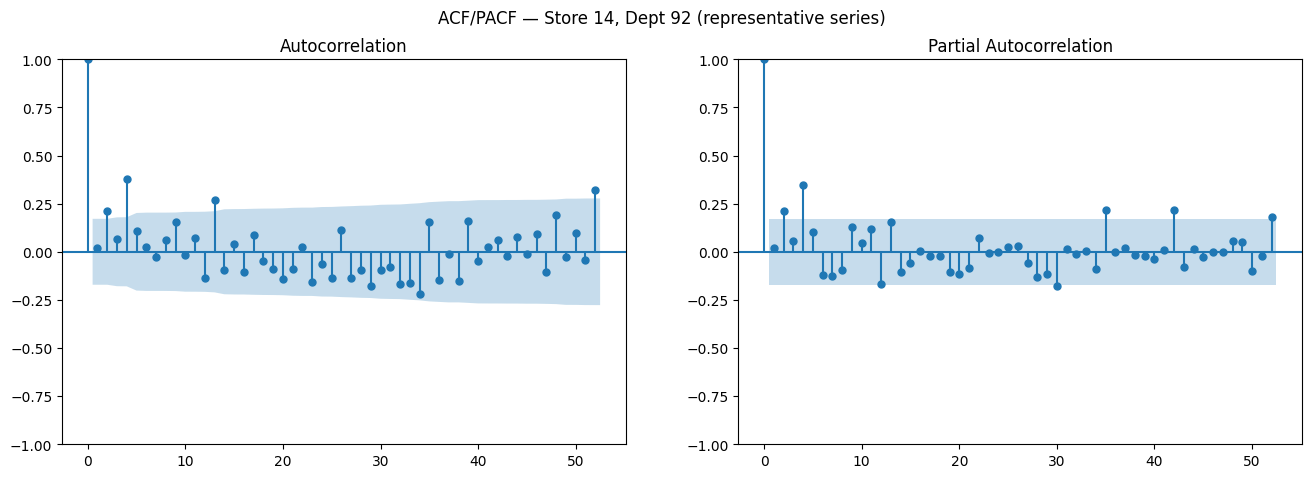

Representative series: Store 14, Dept 92
Order selected: SARIMA(1,1,1)(1,1,1,52)
🏃 View run SARIMA_Order_Selection at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0/runs/70f18dd2dafd49d1815596031db54068
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0


In [ ]:
with mlflow.start_run(run_name="SARIMA_Order_Selection"):
    rep_store, rep_dept = volume_by_pair.index[0]
    subset = processed_train[
        (processed_train['Store'] == rep_store) &
        (processed_train['Dept'] == rep_dept)
    ].sort_values('Date')
    rep_series = subset.set_index('Date')['Weekly_Sales'][:-12]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_acf(rep_series, lags=52, ax=axes[0])
    plot_pacf(rep_series, lags=52, ax=axes[1])
    plt.suptitle(f'ACF/PACF — Store {rep_store}, Dept {rep_dept} (representative series)')
    acf_path = f"{drive_repo}/sarima_acf_pacf.png"
    plt.savefig(acf_path)
    plt.show()

    mlflow.log_param("p", 1)
    mlflow.log_param("d", 1)
    mlflow.log_param("q", 1)
    mlflow.log_param("P", 1)
    mlflow.log_param("D", 1)
    mlflow.log_param("Q", 1)
    mlflow.log_param("s", 52)
    mlflow.log_param("order_selection_method", "ACF_PACF_analysis")
    mlflow.log_param("representative_series", f"Store_{rep_store}_Dept_{rep_dept}")
    mlflow.log_param(
        "order_reasoning",
        "d=1: most individual series non-stationary unlike aggregate. "
        "p=1,q=1: single significant spike in PACF/ACF at lag 1. "
        "D=1,s=52: strong lag-52 spike in ACF confirms yearly seasonality. "
        "P=1,Q=1: standard starting point for seasonal component."
    )
    mlflow.log_artifact(acf_path)

    print(f"Representative series: Store {rep_store}, Dept {rep_dept}")
    print("Order selected: SARIMA(1,1,1)(1,1,1,52)")

In [9]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

In [10]:
def fit_and_evaluate_sarima(series_df, store, dept, n_test=12, order=(1,1,1), seasonal_order=(1,1,1,52)):
    subset = series_df[
        (series_df['Store'] == store) &
        (series_df['Dept'] == dept)
    ].sort_values('Date')
    series = subset.set_index('Date')['Weekly_Sales']

    if len(series) < n_test + seasonal_order[3] + 10:
        return None

    train_series = series[:-n_test]
    val_series = series[-n_test:]
    holiday_val = subset['IsHoliday'].iloc[-n_test:].values

    try:
        model = SARIMAX(
            train_series,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        forecast = results.get_forecast(steps=n_test)
        pred_mean = forecast.predicted_mean

        mae = mean_absolute_error(val_series, pred_mean)
        rmse = np.sqrt(np.mean((val_series.values - pred_mean.values) ** 2))
        w_mae = wmae(val_series.values, pred_mean.values, holiday_val)

        return {
            'Store': store, 'Dept': dept,
            'n_weeks': len(series),
            'adf_pvalue': adfuller(train_series)[1],
            'mae': mae, 'rmse': rmse, 'wmae': w_mae, 'aic': results.aic,
            'series': series,
            'train_series': train_series,
            'val_series': val_series,
            'pred_mean': pred_mean,
            'results': results
        }
    except Exception as e:
        print(f"Failed — Store {store}, Dept {dept}: {e}")
        return None

In [11]:
sarima_configs = [
    {"run_name": "SARIMA_Baseline_111_111_52", "order": (1,1,1), "seasonal_order": (1,1,1,52)},
    {"run_name": "SARIMA_Order_211_111_52",    "order": (2,1,1), "seasonal_order": (1,1,1,52)},
    {"run_name": "SARIMA_Order_112_111_52",    "order": (1,1,2), "seasonal_order": (1,1,1,52)},
    {"run_name": "SARIMA_Seasonal_011_52",     "order": (1,1,1), "seasonal_order": (0,1,1,52)},
    {"run_name": "SARIMA_Seasonal_110_52",     "order": (1,1,1), "seasonal_order": (1,1,0,52)},
    {"run_name": "SARIMA_NoDiff_101_101_52",   "order": (1,0,1), "seasonal_order": (1,0,1,52)},
]

In [12]:
import gc

sweep_results = []

for config in sarima_configs:
    with mlflow.start_run(run_name=config["run_name"]):
        mlflow.log_param("order", str(config["order"]))
        mlflow.log_param("seasonal_order", str(config["seasonal_order"]))

        metrics_only = []

        for store, dept in sample_pairs:
            result = fit_and_evaluate_sarima(
                processed_train, store, dept,
                n_test=12,
                order=config["order"],
                seasonal_order=config["seasonal_order"],
            )
            if result is not None:
                metrics_only.append({
                    'Store': result['Store'], 'Dept': result['Dept'],
                    'mae': result['mae'], 'rmse': result['rmse'],
                    'wmae': result['wmae'], 'aic': result['aic']
                })
            del result

        summary_df = pd.DataFrame(metrics_only)

        mean_mae = summary_df['mae'].mean()
        median_mae = summary_df['mae'].median()
        mean_rmse = summary_df['rmse'].mean()
        mean_wmae = summary_df['wmae'].mean()
        median_wmae = summary_df['wmae'].median()
        mean_aic = summary_df['aic'].mean()

        mlflow.log_metric("mean_mae", mean_mae)
        mlflow.log_metric("median_mae", median_mae)
        mlflow.log_metric("mean_rmse", mean_rmse)
        mlflow.log_metric("mean_wmae", mean_wmae)
        mlflow.log_metric("median_wmae", median_wmae)
        mlflow.log_metric("mean_aic", mean_aic)
        mlflow.log_metric("n_series_evaluated", len(metrics_only))

        sweep_results.append({
            "run_name": config["run_name"],
            "order": config["order"],
            "seasonal_order": config["seasonal_order"],
            "mean_mae": mean_mae,
            "mean_rmse": mean_rmse,
            "mean_wmae": mean_wmae,
            "median_wmae": median_wmae,
        })

        print(f"{config['run_name']}: mean_mae={mean_mae:.2f}, mean_wmae={mean_wmae:.2f}")

        gc.collect()

SARIMA_Baseline_111_111_52: mean_mae=1581.47, mean_wmae=1596.47
🏃 View run SARIMA_Baseline_111_111_52 at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0/runs/1c7697cb34504b42b055d5b90c9c9425
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0
SARIMA_Order_211_111_52: mean_mae=1757.95, mean_wmae=1669.84
🏃 View run SARIMA_Order_211_111_52 at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0/runs/db248d60630d4910af9fb9f47920c08b
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0
SARIMA_Order_112_111_52: mean_mae=1872.20, mean_wmae=1834.53
🏃 View run SARIMA_Order_112_111_52 at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0/runs/92d93d839f6a4aa797a3cd622dfc1d1b
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0
SARIMA_Seasonal_011_52: mean_mae=1598.11, mean_wmae=1556.42
🏃 View run SARIMA_Seasonal_011_52 at: https://

In [13]:
from tqdm.auto import tqdm
from sklearn.base import BaseEstimator, RegressorMixin

class MultiSeriesSARIMA(BaseEstimator, RegressorMixin):
    def __init__(self, order=(1,1,1), seasonal_order=(0,1,1,52)):
        self.order = order
        self.seasonal_order = seasonal_order

    def fit(self, X, y=None):
        self.models_ = {}
        self.skipped_series_ = []
        groups = list(X.groupby(['Store', 'Dept']))

        for (store, dept), grp in tqdm(groups, desc="Fitting SARIMA per series"):
            grp = grp.sort_values('Date')
            series = grp.set_index('Date')['Weekly_Sales']

            if len(series) < self.seasonal_order[3] + 10:
                self.skipped_series_.append((store, dept, len(series)))
                continue

            try:
                model = SARIMAX(
                    series,
                    order=self.order,
                    seasonal_order=self.seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                self.models_[(store, dept)] = model.fit(disp=False)
            except Exception:
                self.skipped_series_.append((store, dept, len(series)))

        self.global_mean_ = X['Weekly_Sales'].mean()

        if self.skipped_series_:
            print(f"Skipped {len(self.skipped_series_)} series "
                  f"(will use global mean fallback at predict time).")

        return self

    def predict(self, X):
        preds = pd.Series(index=X.index, dtype=float)

        for (store, dept), grp in X.groupby(['Store', 'Dept']):
            grp = grp.sort_values('Date')
            key = (store, dept)
            n_steps = len(grp)

            if key in self.models_:
                forecast = self.models_[key].get_forecast(steps=n_steps)
                preds.loc[grp.index] = forecast.predicted_mean.values
            else:
                preds.loc[grp.index] = self.global_mean_

        return preds.values

In [14]:
best_config = min(sweep_results, key=lambda r: r['mean_wmae'])

print(f"Best config from sweep: {best_config['run_name']}")
print(f"  order={best_config['order']}, seasonal_order={best_config['seasonal_order']}")
print(f"  mean_wmae={best_config['mean_wmae']:.2f}")

Best config from sweep: SARIMA_Seasonal_011_52
  order=(1, 1, 1), seasonal_order=(0, 1, 1, 52)
  mean_wmae=1556.42


In [15]:
with mlflow.start_run(run_name="SARIMA_Final_Refit"):
    mlflow.log_param("order", str(best_config["order"]))
    mlflow.log_param("seasonal_order", str(best_config["seasonal_order"]))
    mlflow.log_param("selected_by", "min_mean_wmae_from_sweep")
    mlflow.log_param("n_series", len(sample_pairs))

    fitted = {}
    skipped = []

    for store, dept in tqdm(sample_pairs, desc="Refitting best config on full series"):
        subset = processed_train[
            (processed_train['Store'] == store) &
            (processed_train['Dept'] == dept)
        ].sort_values('Date')
        series = subset.set_index('Date')['Weekly_Sales'].asfreq('W-FRI')

        if len(series) < best_config["seasonal_order"][3] + 10:
            skipped.append((store, dept))
            continue

        try:
            model = SARIMAX(
                series,
                order=best_config["order"],
                seasonal_order=best_config["seasonal_order"],
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted[(store, dept)] = model.fit(disp=False)
        except Exception:
            skipped.append((store, dept))

    mlflow.log_metric("n_series_fit", len(fitted))
    mlflow.log_metric("n_series_skipped", len(skipped))
    print(f"Fitted: {len(fitted)} / {len(sample_pairs)}   Skipped: {len(skipped)}")

Refitting best config on full series:   0%|          | 0/15 [00:00<?, ?it/s]

Fitted: 15 / 15   Skipped: 0
🏃 View run SARIMA_Final_Refit at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0/runs/6285b1b183d648839d2695f6f1fe09b9
🧪 View experiment at: https://dagshub.com/aochi23/ml_final_project.mlflow/#/experiments/0


In [16]:
from sklearn.pipeline import Pipeline

sarima_model = MultiSeriesSARIMA(order=best_config["order"], seasonal_order=best_config["seasonal_order"])
sarima_model.models_ = fitted
sarima_model.skipped_series_ = skipped
sarima_model.global_mean_ = processed_train['Weekly_Sales'].mean()

best_sarima_pipeline = Pipeline([
    ('sarima', sarima_model)
])

print(f"Reconstructed pipeline — {len(sarima_model.models_)} series fit, "
      f"{len(sarima_model.skipped_series_)} skipped")

Reconstructed pipeline — 15 series fit, 0 skipped


In [ ]:
with mlflow.start_run(run_name="SARIMA_MultiSeries_Final"):
    mlflow.log_param("order", str(best_config["order"]))
    mlflow.log_param("seasonal_order", str(best_config["seasonal_order"]))
    mlflow.log_param("selected_from_sweep", best_config["run_name"])
    mlflow.log_param("n_series_fit", len(best_sarima_pipeline.named_steps['sarima'].models_))
    mlflow.log_param("n_series_skipped", len(best_sarima_pipeline.named_steps['sarima'].skipped_series_))
    mlflow.log_param("sampling_strategy", "stratified_by_volume_5_5_5 (same 15 series used in sweep)")

    mlflow.log_metric("sweep_mean_mae", best_config['mean_mae'])
    mlflow.log_metric("sweep_mean_wmae", best_config['mean_wmae'])
    mlflow.log_metric("sweep_median_wmae", best_config['median_wmae'])

    mlflow.sklearn.log_model(
        sk_model=best_sarima_pipeline,
        name="sarima_multiseries_pipeline",
        registered_model_name="SARIMA_Pipeline",
        serialization_format="cloudpickle",
    )

    print(f"Saved SARIMA pipeline — {len(best_sarima_pipeline.named_steps['sarima'].models_)} series fit, "
          f"sweep mean_wmae={best_config['mean_wmae']:.2f}")

2026/07/11 15:07:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
